# CDC + Earthquake GAS Workflow

This notebook demonstrates a GAS SDK workflow focused on:

1. Data downloading with `geospatial_data_retrieval_agent`.
2. Vector analysis with `vector_analysis_agent`.
3. Static cartographic output with `mapping_agent`.
4. Web mapping app development with `web_mapping_app_agent`.

All service calls use `mode="stream"` so progress messages are visible while each agent works.

The workflow uses two no-key public data sources:

- **CDC PLACES** for county-level health data.
- **USGS Earthquake** for recent earthquake event data.

## Install GAS Client SDK

This notebook uses the published `gas-client` package from PyPI. Run this cell once in a new notebook environment.


In [17]:
%pip install -q -U gas-client


Note: you may need to restart the kernel to use updated packages.


ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'd:\\gas\\.venv\\lib\\site-packages\\81d243bd2c585b0f4821__mypyc.cp314-win_amd64.pyd'
Check the permissions.



## Imports

In [1]:
import os
from pathlib import Path
from urllib.parse import urljoin

from IPython.display import HTML, Image, display
from dotenv import load_dotenv
project_root = Path.cwd()
if project_root.name == "examples_for_using_gas_services":
    project_root = project_root.parent

from gas_client import GasClient
from importlib.metadata import version

print("gas-client", version("gas-client"))


gas-client 0.2.2


## User Settings

Start the GAS server first. For local development, keep `server_url` as `http://127.0.0.1:4042`.

CDC PLACES and USGS Earthquake do not require source API keys. The OpenAI key is still needed because these agents use model-backed reasoning.

In [2]:
load_dotenv(project_root / ".env")

server_url =  "http://127.0.0.1:4042"

openai_api_key = os.getenv("OPENAI_API_KEY")
if not openai_api_key:
    raise RuntimeError("Set OPENAI_API_KEY in the repo .env file before running this notebook.")

timeout_seconds = 900
client = GasClient(
    server_url,
    default_credentials={"OPENAI_API_KEY": openai_api_key},
    artifact_delivery="URL",
)

credentials = {
    "OPENAI_API_KEY": openai_api_key,
}


## Discover Agents

In [3]:
client.list_agents()

['exploratory_spatial_data_analysis_agent',
 'geospatial_data_inspection_agent',
 'geospatial_data_retrieval_agent',
 'geospatial_workflow_planning_agent',
 'google_earth_engine_agent',
 'map_projection_agent',
 'mapping_agent',
 'pasda_agent',
 'raster_agent',
 'spatial_analysis_agent',
 'spatial_statistics_agent',
 'spatiotemporal_conflict_event_agent',
 'usgs_earthquake_agent',
 'vector_analysis_agent',
 'web_mapping_app_agent']

In [4]:
data_agent = client.agent("geospatial_data_retrieval_agent")
vector_agent = client.agent("vector_analysis_agent")
mapping_agent = client.agent("mapping_agent")
web_mapping_app_agent = client.agent("web_mapping_app_agent")

for agent in [data_agent, vector_agent, mapping_agent, web_mapping_app_agent]:
    print(agent.agent_id, agent.status().get("status"))

if not hasattr(data_agent, "run_streaming_task"):
    raise RuntimeError(
        "This notebook needs gas-client>=0.2.2. Run the install cell, restart the kernel, "
        "and re-run the imports before continuing."
    )


geospatial_data_retrieval_agent available
vector_analysis_agent available
mapping_agent available
web_mapping_app_agent available


## SDK Helper Usage

The workflow uses the agent-bound `run_streaming_task(...)` helper plus SDK artifact helpers for URL selection and display.

In [5]:
# Artifact handling uses the GAS Client SDK helpers directly.
# Use client.get_artifacts(...), client.get_artifact_urls(...),
# client.print_artifacts(...), and client.display_artifacts(...).


## Part 1: Download Contiguous US County Boundaries

First, use the data retrieval agent to download the county boundary geometry for the contiguous United States. This becomes the geometry layer for the later join and choropleth map.

In [9]:
county_boundary_result = data_agent.run_streaming_task((
        "Use the US Census Bureau boundary source. Download county boundaries for the contiguous United States. "
        "Exclude Alaska, Hawaii, Puerto Rico, and other territories."
    ),
)

county_boundary_url = client.get_artifact_urls(county_boundary_result)[0]
county_boundary_url

[11:34:16] stream_connected: Streaming connection established.
[11:34:16] Geospatial Data Retrieval Agent: I received your request.
[11:34:16] Geospatial Data Retrieval Agent: I need to inspect the request text and any provided dataset references before running the agent. I found 0 dataset reference(s).
[11:34:16] Geospatial Data Retrieval Agent: I found the required credentials and can start the model-backed workflow.
[11:34:16] task_accepted: Task accepted. Starting streaming execution.
[11:34:17] Geospatial Data Retrieval Agent: Next I will start the workflow with the prepared inputs.
[11:34:17] Geospatial Data Retrieval Agent: I am checking whether the request asks for one dataset or several.
[11:34:18] Geospatial Data Retrieval Agent: The request was decomposed into 1 sub-request(s).
[11:34:18] Geospatial Data Retrieval Agent: I will identify the most suitable supported data source, then generate source-specific download logic.
[11:34:18] Geospatial Data Retrieval Agent: I am comp

'http://127.0.0.1:4042/agents/geospatial_data_retrieval_agent/data/geospatial_data_retrieval_agent-8024-tesw-8476.gpkg'

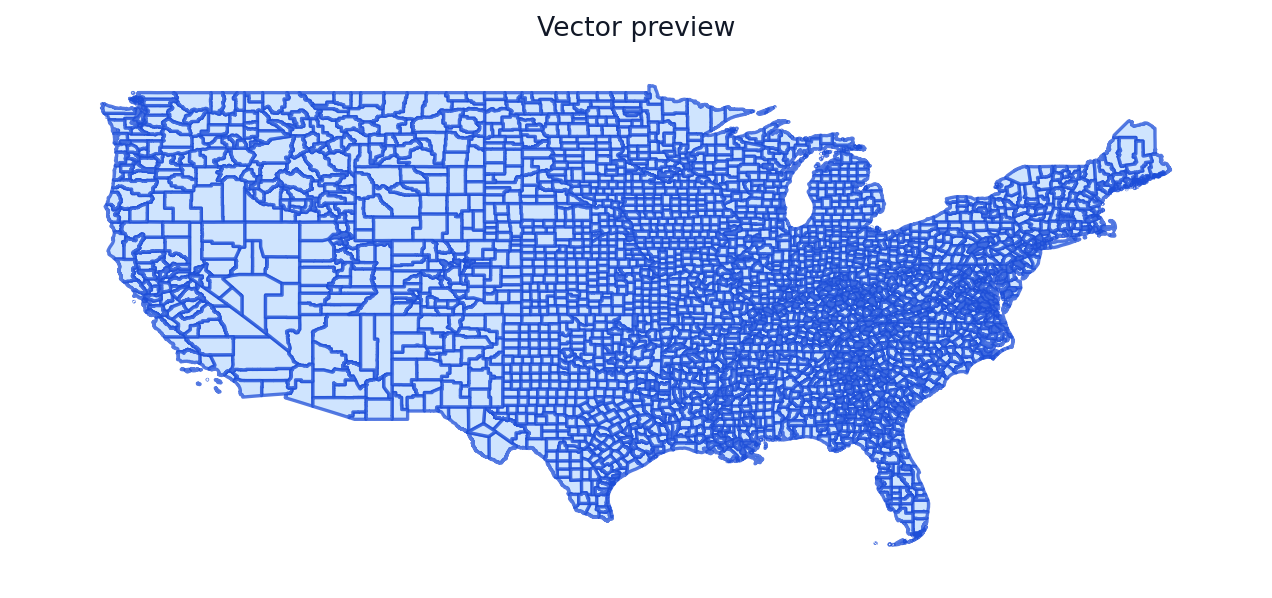

STATEFP,COUNTYFP,COUNTYNS,AFFGEOID,GEOID,NAME,NAMELSAD,STUSPS,STATE_NAME,LSAD,ALAND,AWATER
20,161,00485044,0500000US20161,20161,Riley,Riley County,KS,Kansas,06,1579077672,32047392
19,159,00465268,0500000US19159,19159,Ringgold,Ringgold County,IA,Iowa,06,1386932347,8723135
30,009,01720111,0500000US30009,30009,Carbon,Carbon County,MT,Montana,06,5303728455,35213028
16,007,00395090,0500000US16007,16007,Bear Lake,Bear Lake County,ID,Idaho,06,2527123155,191364281
55,011,01581065,0500000US55011,55011,Buffalo,Buffalo County,WI,Wisconsin,06,1750290818,87549529


In [10]:
client.display_artifacts(county_boundary_result)

## Part 2: Download 2020 County-Level Obesity Rates from CDC PLACES

Next, use the data retrieval agent again to download an attribute table or geospatial dataset containing county-level adult obesity prevalence for 2021. The vector analysis agent will join this to the county boundaries.

In [11]:
obesity_result = data_agent.run_streaming_task((
        "Download 2020 county-level adult obesity prevalence estimates "
        "for the contiguous United States. Return one clean CSV dataset with county FIPS/GEOID, county name, "
        "state identifier, year, measure name, and the obesity prevalence value."
    ),
)

obesity_url = client.get_artifact_urls(obesity_result)[0]
obesity_url

[11:35:35] stream_connected: Streaming connection established.
[11:35:35] Geospatial Data Retrieval Agent: I received your request.
[11:35:35] Geospatial Data Retrieval Agent: I need to inspect the request text and any provided dataset references before running the agent. I found 0 dataset reference(s).
[11:35:35] Geospatial Data Retrieval Agent: I found the required credentials and can start the model-backed workflow.
[11:35:35] task_accepted: Task accepted. Starting streaming execution.
[11:35:36] Geospatial Data Retrieval Agent: Next I will start the workflow with the prepared inputs.
[11:35:36] Geospatial Data Retrieval Agent: I am checking whether the request asks for one dataset or several.
[11:35:37] Geospatial Data Retrieval Agent: The request was decomposed into 1 sub-request(s).
[11:35:37] Geospatial Data Retrieval Agent: I will identify the most suitable supported data source, then generate source-specific download logic.
[11:35:37] Geospatial Data Retrieval Agent: I am comp

'http://127.0.0.1:4042/agents/geospatial_data_retrieval_agent/data/geospatial_data_retrieval_agent-2057-teku-2724.csv'

In [12]:
client.display_artifacts(obesity_result)

locationid,locationname,stateabbr,year,measureid,data_value,FIPS_Code,County_Name,State,Year,Measure,Obesity_Prevalence
01001,Autauga,AL,2020,OBESITY,37.6,01001,Autauga,AL,2020,OBESITY,37.6
01001,Autauga,AL,2020,OBESITY,37.3,01001,Autauga,AL,2020,OBESITY,37.3
01003,Baldwin,AL,2020,OBESITY,32.9,01003,Baldwin,AL,2020,OBESITY,32.9
01003,Baldwin,AL,2020,OBESITY,32.6,01003,Baldwin,AL,2020,OBESITY,32.6
01005,Barbour,AL,2020,OBESITY,46.1,01005,Barbour,AL,2020,OBESITY,46.1


## Part 3: Join County Boundaries with Obesity Rates

The vector analysis agent receives both datasets and creates one mapping-ready GeoJSON. The join should use county GEOID/FIPS fields and preserve the county boundary geometry.

In [14]:
obesity_join_result = vector_agent.run_streaming_task((
        "Join the contiguous US county boundary dataset with the 2020 county-level adult obesity prevalence dataset. "
        "Create a clean numeric field named obesity_rate for the obesity prevalence value. Keep county name, state, GEOID, "
        "year, and measure fields when available. Exclude unmatched non-contiguous records if present. Return one GeoJSON "
        "artifact ready for choropleth mapping."
    ),
    input_datasets=[county_boundary_url, obesity_url],
)

obesity_join_url = client.get_artifact_urls(obesity_join_result)[0]
obesity_join_url

[11:37:24] stream_connected: Streaming connection established.
[11:37:24] Vector Analysis Agent: I received your request.
[11:37:24] Vector Analysis Agent: I need to inspect the request text and any provided dataset references before running the agent. I found 2 dataset reference(s).
[11:37:24] Vector Analysis Agent: I found the required credentials and can start the model-backed workflow.
[11:37:24] task_accepted: Task accepted. Starting streaming execution.
[11:37:25] Vector Analysis Agent: Next I will start the workflow with the prepared inputs.
[11:37:25] Vector Analysis Agent: I will load the requested vector/tabular inputs, run code-driven analysis, and save a final dataset artifact from 2 dataset reference(s).
[11:37:25] Vector Analysis Agent: I detected a common vector operation and will first try a deterministic GeoPandas workflow.
[11:37:28] Vector Analysis Agent: Joined 3108 spatial features with 6218 table/vector records using GEOID = FIPS_Code. Matched 3108 output feature(

'http://127.0.0.1:4042/agents/vector_analysis_agent/data/vector_analysis_agent-5635-hxug-0028.geojson'

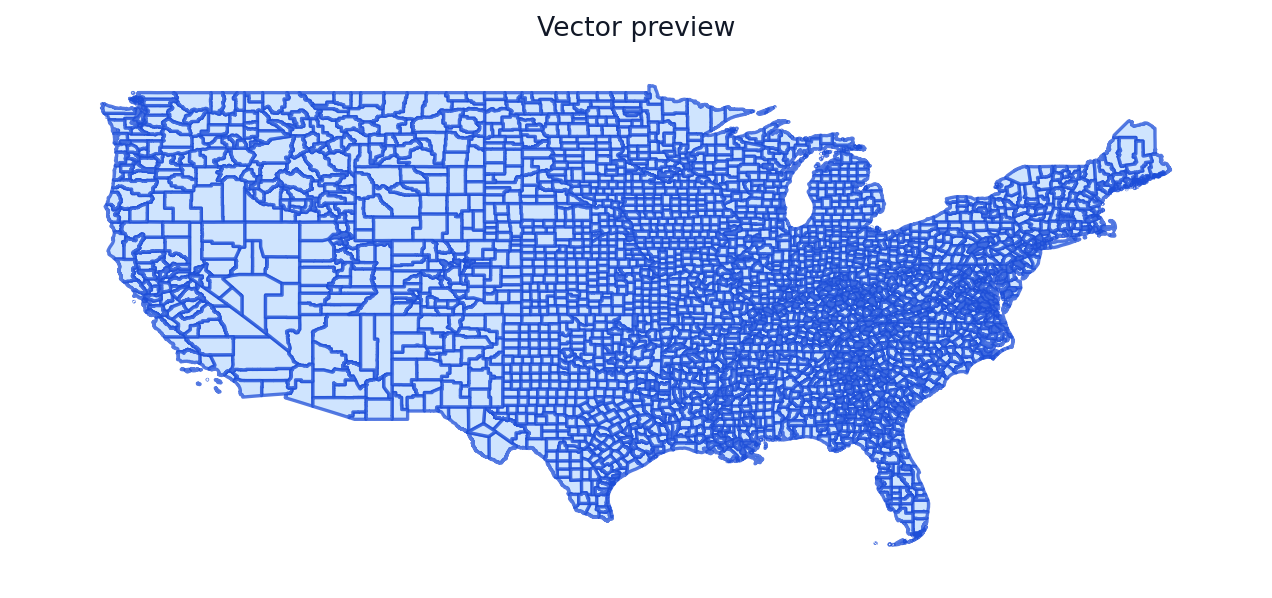

STATEFP,COUNTYFP,COUNTYNS,AFFGEOID,GEOID,NAME,NAMELSAD,STUSPS,STATE_NAME,LSAD,ALAND,AWATER
20,161,00485044,0500000US20161,20161,Riley,Riley County,KS,Kansas,06,1579077672,32047392
19,159,00465268,0500000US19159,19159,Ringgold,Ringgold County,IA,Iowa,06,1386932347,8723135
30,009,01720111,0500000US30009,30009,Carbon,Carbon County,MT,Montana,06,5303728455,35213028
16,007,00395090,0500000US16007,16007,Bear Lake,Bear Lake County,ID,Idaho,06,2527123155,191364281
55,011,01581065,0500000US55011,55011,Buffalo,Buffalo County,WI,Wisconsin,06,1750290818,87549529


In [15]:
client.display_artifacts(county_boundary_result)

## Part 4: Static Choropleth Map of County Obesity Rates

The static `mapping_agent` creates a presentation-ready PNG choropleth map from the joined county geometry and obesity attribute dataset.

[11:38:07] stream_connected: Streaming connection established.
[11:38:08] Mapping Agent: I received your request.
[11:38:08] Mapping Agent: I need to inspect the request text and any provided dataset references before running the agent. I found 1 dataset reference(s).
[11:38:08] Mapping Agent: I found the required credentials and can start the model-backed workflow.
[11:38:08] task_accepted: Task accepted. Starting streaming execution.
[11:38:08] Mapping Agent: Next I will start the workflow with the prepared inputs.
[11:38:08] Mapping Agent: I will inspect the requested visualization and the 1 dataset reference(s), then choose whether a map or chart is the best way to answer it.
[11:38:11] Mapping Agent: I am drafting visualization code now. This is attempt 1; I will run the code and check whether it creates the requested output correctly.
[11:38:21] Mapping Agent: Still working on map_design: I am drafting visualization code now. This is attempt 1; I will run the code and check wheth

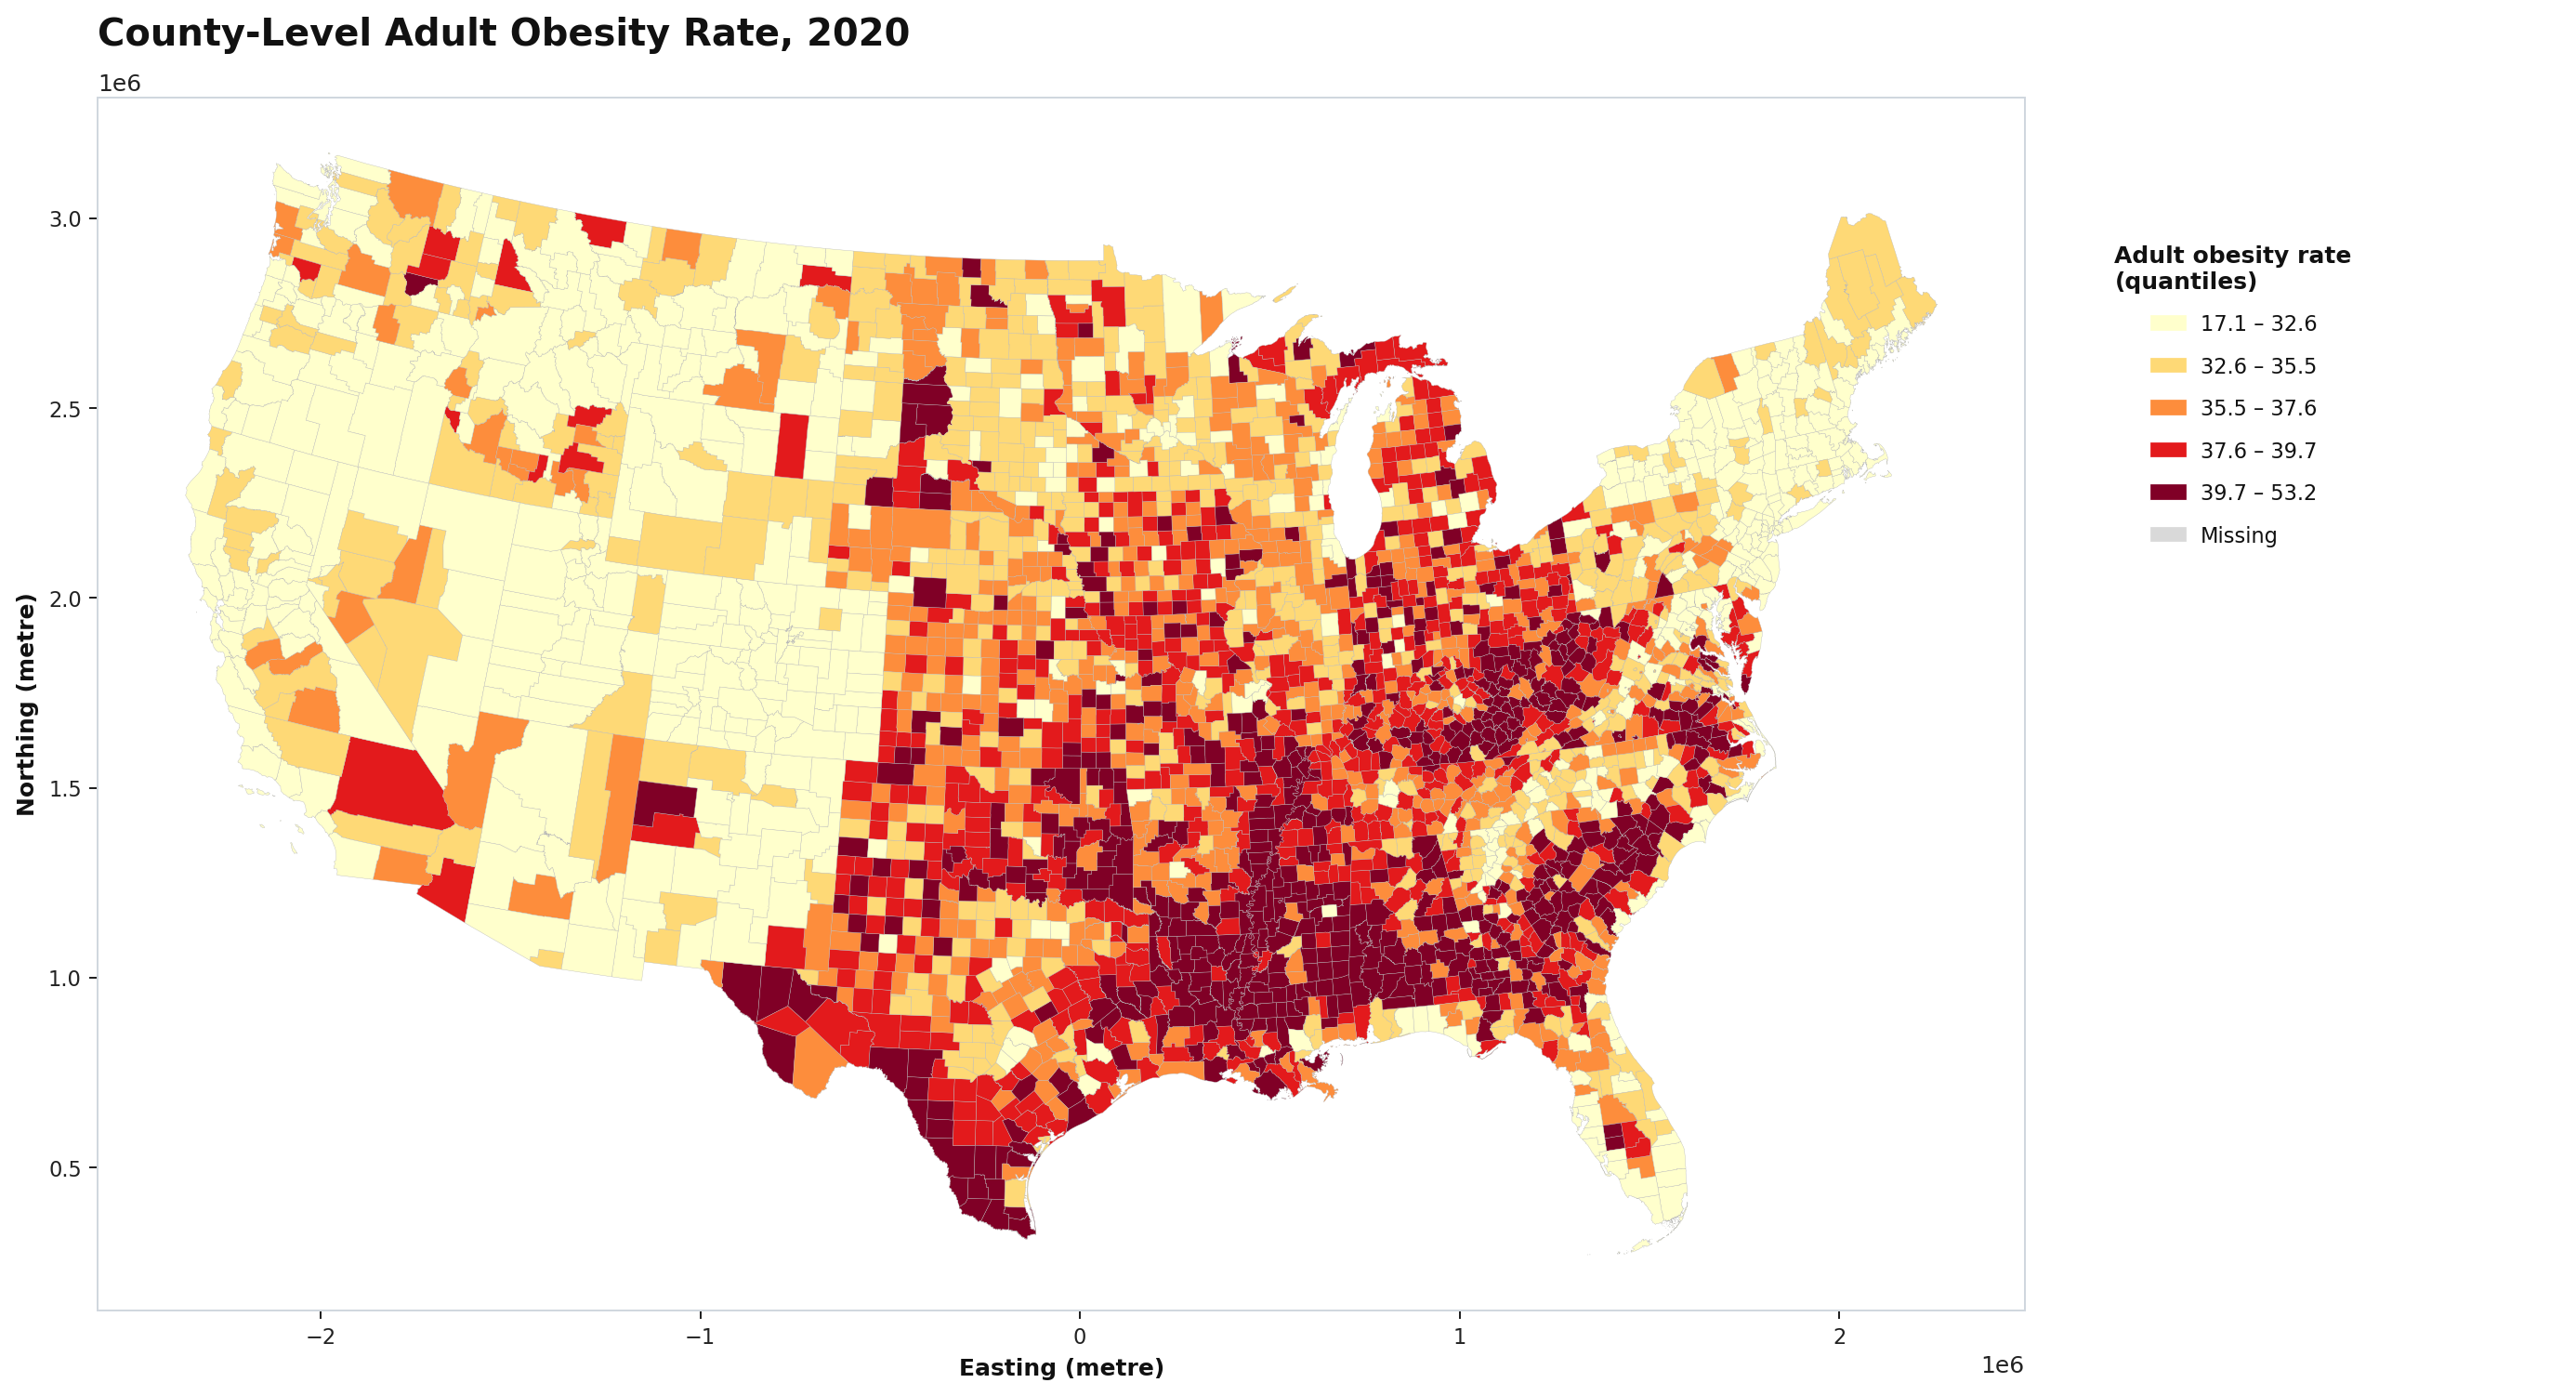

In [16]:
obesity_map_result = mapping_agent.run_streaming_task((
        "Create a professional county-level choropleth map for the contiguous United States showing 2020 adult obesity rate. "
        "Use the obesity_rate field for color. Use 5 quantile classes, a clear sequential color scheme, thin county outlines, "
        "missing values in light gray, a legend outside the map axes, and the title 'County-Level Adult Obesity Rate, 2020'." \
        "Use the Albers Equal Area projection. " \
    ),
    input_datasets=[obesity_join_url],
)

client.display_artifacts(obesity_map_result)


## Part 5: Download USGS Earthquake Data

This request uses the USGS Earthquake source. The output will be used by the web mapping app agent.

In [51]:
earthquake_result = data_agent.run_streaming_task((
        "Use the USGS Earthquake data source. Download recent earthquakes from the last 30 days "
        "with magnitude 2.0 or greater for California and nearby areas. Return one GeoJSON point dataset with event time, magnitude, "
        "place/location description, depth, event id, and geometry. "
    ),
)

earthquake_url = client.get_artifact_urls(earthquake_result)[0]
earthquake_url

[15:58:01] stream_connected: Streaming connection established.
[15:58:02] Geospatial Data Retrieval Agent: I received your request.
[15:58:02] Geospatial Data Retrieval Agent: I need to inspect the request text and any provided dataset references before running the agent. I found 0 dataset reference(s).
[15:58:02] Geospatial Data Retrieval Agent: I found the required credentials and can start the model-backed workflow.
[15:58:02] task_accepted: Task accepted. Starting streaming execution.
[15:58:02] Geospatial Data Retrieval Agent: Next I will start the workflow with the prepared inputs.
[15:58:03] Geospatial Data Retrieval Agent: I am checking whether the request asks for one dataset or several.
[15:58:04] Geospatial Data Retrieval Agent: The request was decomposed into 1 sub-request(s).
[15:58:04] Geospatial Data Retrieval Agent: I will identify the most suitable supported data source, then generate source-specific download logic.
[15:58:04] Geospatial Data Retrieval Agent: I am comp

'http://127.0.0.1:4042/agents/geospatial_data_retrieval_agent/data/geospatial_data_retrieval_agent-4869-eban-6158.geojson'

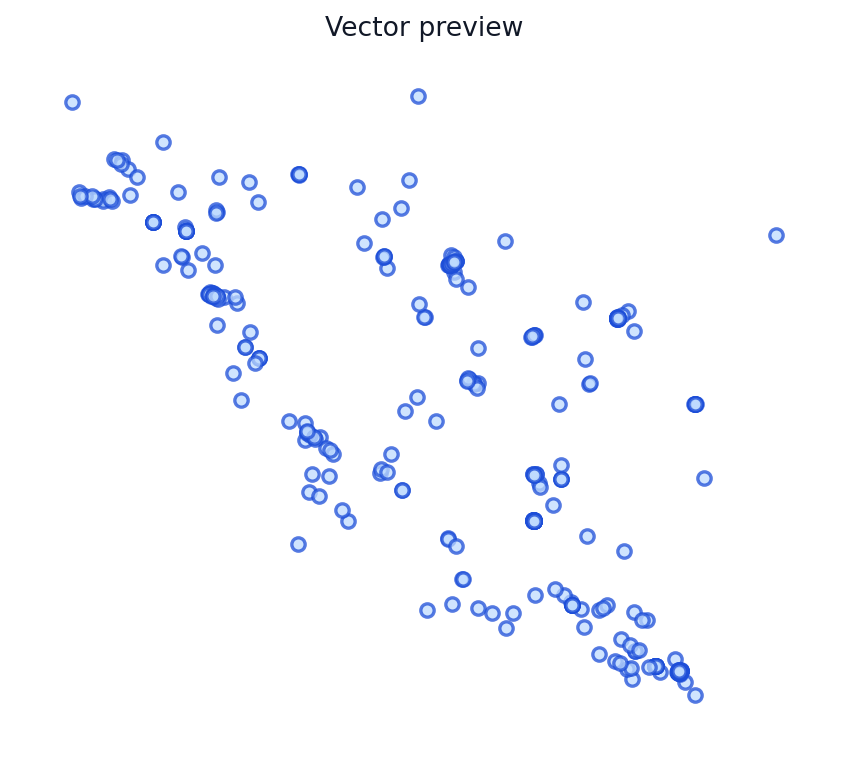

event_time,magnitude,place,depth,event_id
1780357269560,2.66,"17 km WSW of Johannesburg, CA",7.9,ci41478304
1780356932868,2.17,"63 km WNW of Beatty, Nevada",7.0031,nn00919566
1780354582890,2.79,"17 km WSW of Johannesburg, CA",7.24,ci41478208
1780353241120,4.05890859090661,"18 km WSW of Johannesburg, CA",7.64,ci41478192
1780348771793,2.0,"56 km S of Kingston, Nevada",3.5258,nn00919548


In [53]:
client.display_artifacts(earthquake_result)

## Part 6: Interactive Earthquake Map

The web mapping app agent creates a browser-ready HTML web mapping app from the earthquake points. It should include a map, layer control, popups, a legend, a professional title, and app-style layout where useful.

In [56]:
earthquake_map_result = web_mapping_app_agent.run_streaming_task((
        "Create a polished web mapping app of the earthquake events. Use circle markers colored and sized by magnitude "
        "using quantile classification. Make sure the marker size and color scheme effectively communicate the magnitude differences," \
        "and don't make the circle too large to obscure the map. " 
        "Include popups with event time, magnitude, depth, place, and event id. "
        "Include a layer control, a visible legend, a professional title, and an initial extent that fits all events. "
        "Use a clean basemap suitable for earthquake visualization. "
        "Make sure the left panel is aligned well with the map window. "
    ),
    input_datasets=[earthquake_url],
)

[16:04:34] stream_connected: Streaming connection established.
[16:04:34] Web Mapping App Agent: I received your request.
[16:04:34] Web Mapping App Agent: I need to inspect the request text and any provided dataset references before running the agent. I found 1 dataset reference(s).
[16:04:35] Web Mapping App Agent: I found the required credentials and can start the model-backed workflow.
[16:04:35] task_accepted: Task accepted. Starting streaming execution.
[16:04:35] Web Mapping App Agent: Next I will start the workflow with the prepared inputs.
[16:04:35] Web Mapping App Agent: I will inspect the input datasets, design the web mapping app, generate the app code, and save an HTML artifact.
[16:04:35] Web Mapping App Agent: I am inspecting 1 dataset reference(s) to identify formats, CRS, geometry types, fields, and bounds.
[16:04:36] Web Mapping App Agent: Dataset inspection and Leaflet-ready input preparation are complete. I have enough metadata to prepare the web mapping app genera

In [57]:
client.display_artifacts(earthquake_map_result)

## Inspect Final Artifact URLs

In [60]:
workflow_outputs = {
    "county_boundaries": county_boundary_url,
    "cdc_obesity_rates": obesity_url,
    "joined_obesity_counties": obesity_join_url,
    "earthquake_download": earthquake_url,
}

workflow_outputs


{'county_boundaries': 'http://127.0.0.1:4042/agents/geospatial_data_retrieval_agent/data/geospatial_data_retrieval_agent-8024-tesw-8476.gpkg',
 'cdc_obesity_rates': 'http://127.0.0.1:4042/agents/geospatial_data_retrieval_agent/data/geospatial_data_retrieval_agent-2057-teku-2724.csv',
 'joined_obesity_counties': 'http://127.0.0.1:4042/agents/vector_analysis_agent/data/vector_analysis_agent-5635-hxug-0028.geojson',
 'earthquake_download': 'http://127.0.0.1:4042/agents/geospatial_data_retrieval_agent/data/geospatial_data_retrieval_agent-4869-eban-6158.geojson'}